In [5]:
# =======================================
# Cell 1 — Imports
# =======================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [6]:
# =======================================
# Cell 2 — Parameters
# =======================================
# Path to your input file (two columns: barcode, count; no header)
INPUT_TSV = 'counts_P0.tsv'

# Output file for the filtered results
OUTPUT_TSV = '/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/3_phenotype_inference/scratch/counts_P0_filtered_e6_1000.tsv'

# Frequency threshold; barcodes with frequency <= this value are REMOVED
FREQ_THRESHOLD = 1e-6

# ✅ NEW PARAMETER: maximum number of barcodes to retain (after filtering)
# Set to None to keep all barcodes passing the frequency threshold.
MAX_BARCODES = 1000   # Example: keep only the top 100k barcodes by frequency

In [7]:
# =======================================
# Cell 3 — Load the TSV (barcode\tcount)
# =======================================
df = pd.read_csv(
    INPUT_TSV,
    sep=r'\s+',
    header=None,
    names=['barcode', 'count'],
    engine='python',
    comment='#'
)

# Clean up types
df['barcode'] = df['barcode'].astype(str).str.strip()
df['count'] = pd.to_numeric(df['count'], errors='coerce')

# Drop invalid rows
df = df[df['barcode'].str.len() > 0].copy()
df = df.dropna(subset=['count']).copy()

print(f"Loaded {len(df):,} rows from {INPUT_TSV}")
df.head()

Loaded 88,140 rows from counts_P0.tsv


,barcode,count
0,AAAAAAAACAAACGGAATTATAGCATGTGGAA,584.0
1,AAAAAAAACAAACGGATCACTATTCGTAAAGA,2802.0
2,AAAAAAAACTTGGAAAATTACTATTAAACAAG,2324.0
3,AAAAAAAACTTGGAAATGTCAAGGCTAACGAG,178.0
4,AAAAAAAAGTGATGGAACGAAGTCAGTTCTCA,248.0


In [8]:
# =======================================
# Cell 4 — Normalize to frequency
# =======================================
total_counts = df['count'].sum()

if total_counts == 0:
    raise ValueError("Total counts sum to zero — cannot compute frequencies. Check your input.")

df['frequency'] = df['count'] / total_counts
print(f"Total counts: {total_counts:.6f}")
df.head()

Total counts: 156570819.000000


,barcode,count,frequency
0,AAAAAAAACAAACGGAATTATAGCATGTGGAA,584.0,0.000004
1,AAAAAAAACAAACGGATCACTATTCGTAAAGA,2802.0,0.000018
2,AAAAAAAACTTGGAAAATTACTATTAAACAAG,2324.0,0.000015
3,AAAAAAAACTTGGAAATGTCAAGGCTAACGAG,178.0,0.000001
4,AAAAAAAAGTGATGGAACGAAGTCAGTTCTCA,248.0,0.000002


In [9]:
# =======================================
# Cell 5 — Filter by frequency threshold
# =======================================
before = len(df)
filtered = df[df['frequency'] > FREQ_THRESHOLD].copy()
after = len(filtered)
removed = before - after

print(f"Kept {after:,} / {before:,} barcodes (removed {removed:,}).")
print(f"Threshold used: frequency > {FREQ_THRESHOLD:g}")
filtered.head()

Kept 75,123 / 88,140 barcodes (removed 13,017).
Threshold used: frequency > 1e-06


,barcode,count,frequency
0,AAAAAAAACAAACGGAATTATAGCATGTGGAA,584.0,0.000004
1,AAAAAAAACAAACGGATCACTATTCGTAAAGA,2802.0,0.000018
2,AAAAAAAACTTGGAAAATTACTATTAAACAAG,2324.0,0.000015
3,AAAAAAAACTTGGAAATGTCAAGGCTAACGAG,178.0,0.000001
4,AAAAAAAAGTGATGGAACGAAGTCAGTTCTCA,248.0,0.000002


In [10]:
# =======================================
# Cell 6 — Limit by MAX_BARCODES (if set)
# =======================================
if MAX_BARCODES is not None:
    # Sort by frequency descending and take top N
    filtered = filtered.sort_values('frequency', ascending=False).head(MAX_BARCODES).copy()
    print(f"⚠️ Limited output to top {len(filtered):,} barcodes by frequency.")

filtered.head()

⚠️ Limited output to top 1,000 barcodes by frequency.


,barcode,count,frequency
67032,TAAACATAGAAGCCCATAAACAGCTGCATCCA,145063.0,0.000927
31748,CAGGACTGTGAAAGGTATACTACCGGCCGAAG,139403.0,0.000890
8472,AATCACCTTATGCGAGAGACGTTTACACAAGG,124399.0,0.000795
71937,TAGTACCACTGCAAGACTATGTACCCAGAGGA,106625.0,0.000681
56044,GGAATACGATTTTGCATAAACGTTACAGAAAG,92322.0,0.000590


In [11]:
# =======================================
# Cell 7 — Save filtered table (barcode + count only)
# =======================================
Path(OUTPUT_TSV).parent.mkdir(parents=True, exist_ok=True)

filtered[['barcode', 'count']].to_csv(
    OUTPUT_TSV,
    sep='\t',
    index=False,
    header=False
)

print(f"Saved filtered results to: {OUTPUT_TSV}")
print("(2 columns: barcode, count; no header)")

Saved filtered results to: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/3_phenotype_inference/scratch/counts_P0_filtered_e6_1000.tsv
(2 columns: barcode, count; no header)


In [12]:
# =======================================
# Cell 8 — Summary statistics
# =======================================
summary = {
    'n_input': len(df),
    'n_kept': len(filtered),
    'n_removed': len(df) - len(filtered),
    'min_frequency_kept': float(filtered['frequency'].min()) if len(filtered) else None,
    'max_frequency_kept': float(filtered['frequency'].max()) if len(filtered) else None,
    'sum_frequency_kept': float(filtered['frequency'].sum()) if len(filtered) else 0.0,
    'FREQ_THRESHOLD': FREQ_THRESHOLD,
    'MAX_BARCODES': MAX_BARCODES,
}
summary

{'n_input': 88140,
 'n_kept': 1000,
 'n_removed': 87140,
 'min_frequency_kept': 8.556511414812232e-05,
 'max_frequency_kept': 0.0009265008698715435,
 'sum_frequency_kept': 0.1336014471508896,
 'FREQ_THRESHOLD': 1e-06,
 'MAX_BARCODES': 1000}

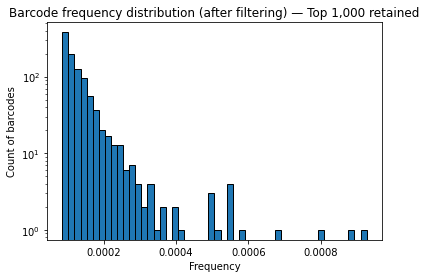

In [13]:
# =======================================
# Cell 9 — Frequency histogram
# =======================================
plt.figure(figsize=(6,4))
plt.hist(filtered['frequency'], bins=50, edgecolor='black')
plt.xlabel("Frequency")
plt.ylabel("Count of barcodes")

# Show top-N in title if capped
title_str = "Barcode frequency distribution (after filtering)"
if MAX_BARCODES is not None:
    title_str += f" — Top {len(filtered):,} retained"
plt.title(title_str)

plt.yscale("log")
plt.show()